# **Experiment Notebook**



---
## Setup Environment

In [121]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

You can now save your data files in: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [122]:
# <Student to fill this section>
student_name = "Aryan Goel"
student_id = "26040826"

In [123]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [124]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [125]:
# 0.a Install Additional Packages


### 0.b Import Packages

In [126]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set(style="whitegrid")
alt.data_transformers.disable_max_rows()
RANDOM_STATE = 42

---
## A. Experiment Description

In [127]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "2"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [128]:
experiment_hypothesis = """
Hypothesis:
A boosting-based sklearn model (HistGradientBoostingClassifier) will outperform Experiment 1 Random Forest on multiclass vitamin-deficiency diagnosis, especially on macro-F1 and balanced accuracy.

Why this is worthwhile:
1) Experiment 1 proved strong non-linear signal capture using Random Forest (bagging).
2) Boosting can iteratively correct hard-to-classify residual errors and may improve minority-class boundaries.
3) If class-balanced metrics improve over Exp1, this indicates a stronger production candidate for reliable personalized vitamin planning.
"""

In [129]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [130]:
experiment_expectations = """
Expected outcome:
- Directly benchmark Experiment 2 against Experiment 1 and baseline.
- Primary metrics: macro_f1 and balanced_accuracy (accuracy as secondary).

Target uplift over Experiment 1:
- macro_f1: +0.01 to +0.04
- balanced_accuracy: +0.01 to +0.03

Possible scenarios:
1) Hypothesis Confirmed: Exp2 improves at least 2/3 primary metrics (macro_f1, balanced_accuracy, accuracy).
2) Hypothesis Partially Confirmed: improves one key metric with acceptable trade-off.
3) Hypothesis Rejected: no meaningful uplift over Exp1, suggesting Exp1 remains champion.
"""

In [131]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [132]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

---
## D. Feature Selection


In [133]:
if isinstance(y_train, pd.DataFrame): y_train = y_train.iloc[:, 0]
if isinstance(y_val, pd.DataFrame): y_val = y_val.iloc[:, 0]
if isinstance(y_test, pd.DataFrame): y_test = y_test.iloc[:, 0]

features_list = X_train.columns.tolist()
print(f"Selected features: {len(features_list)}")
print("Sample feature names:", features_list[:10])

Selected features: 80
Sample feature names: ['age', 'postcode', 'bmi', 'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake', 'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake', 'calcium_intake']


In [134]:
feature_selection_explanations = """
All prepared features are retained for Experiment 2 to preserve a controlled comparison with Experiment 1.
By keeping data splits and feature space constant, performance differences can be attributed primarily to algorithm family change (bagging RF vs boosting HGB), not feature selection variance.
This approach ensures a fair test of the hypothesis regarding the impact of boosting on model performance, without confounding factors from feature engineering or selection.
"""

In [135]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation: "NaN checks (before coercion)"


In [136]:
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

print("\nNaN checks (before coercion):")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_val  :", y_val.isna().sum())
print("y_test :", y_test.isna().sum())

Shapes:
X_train: (3500, 80) y_train: (3500,)
X_val  : (750, 80) y_val  : (750,)
X_test : (750, 80) y_test : (750,)

NaN checks (before coercion):
X_train: 0
X_val  : 0
X_test : 0
y_train: 0
y_val  : 0
y_test : 0


In [137]:
data_transformation_1_explanations = """
This transformation validates split integrity and target vector structure before model training.
It reduces execution risk (shape/NaN issues) and ensures Experiment 2 remains directly comparable to Experiment 1 under the same data protocol.
By confirming that features and targets are properly aligned and free of missing values, we can attribute performance differences to the algorithmic change rather than data quality issues.
"""

In [138]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### E.2 Data Transformation: "NaN checks (after coercion)"


In [139]:
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_val = X_val.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("NaN checks (after coercion/fill):")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

NaN checks (after coercion/fill):
X_train: 0
X_val  : 0
X_test : 0


In [140]:
data_transformation_2_explanations = """
Defensive numeric coercion and train-median backfill ensure stable sklearn-compatible inputs.
This prevents environment-specific dtype drift and preserves leakage safety by using train-only statistics.
While Exp1 may have tolerated some non-numeric or NaN values, this step ensures Exp2's boosting algorithm receives clean, consistent data.
This transformation is crucial for a fair algorithmic comparison, as it eliminates data quality issues as a confounding factor in performance differences between the two experiments.
"""

In [141]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### E.3 Data Transformation: Class Distribution across Test/Val/Train


In [142]:
def class_dist_pct(y):
    return (y.value_counts(normalize=True) * 100).round(2).to_frame("percent")

print("Train class distribution:")
display(class_dist_pct(y_train))

print("Validation class distribution:")
display(class_dist_pct(y_val))

print("Test class distribution:")
display(class_dist_pct(y_test))

Train class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.69
Night_Blindness,4.89
Scurvy,3.23


Validation class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.67
Night_Blindness,4.93
Scurvy,3.20


Test class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.93
Rickets_Osteomalacia,24.67
Night_Blindness,4.80
Scurvy,3.20


In [143]:
data_transformation_3_explanations = """
Class-distribution auditing confirms representative multiclass proportions across splits.
This is critical because macro-level metrics are sensitive to class prevalence, and fair comparison requires stable class composition.
"""

In [144]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### G.n Fixing "Column Alignment and Feature Counts"

> You can add more cells related to data preparation in this section

In [145]:
print("Column alignment:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))
print("Feature counts:", X_train.shape[1], X_val.shape[1], X_test.shape[1])

Column alignment: True
Feature counts: 80 80 80


---
## F. Feature Engineering

### F.1 New Feature "biomarker_gap_d_b12_exp2"



In [146]:
# F.1 New Feature: biomarker_gap_d_b12_exp2
if {"serum_vitamin_d", "serum_vitamin_b12"}.issubset(X_train.columns):
    X_train["biomarker_gap_d_b12_exp2"] = X_train["serum_vitamin_d"] - X_train["serum_vitamin_b12"]
    X_val["biomarker_gap_d_b12_exp2"] = X_val["serum_vitamin_d"] - X_val["serum_vitamin_b12"]
    X_test["biomarker_gap_d_b12_exp2"] = X_test["serum_vitamin_d"] - X_test["serum_vitamin_b12"]
else:
    X_train["biomarker_gap_d_b12_exp2"] = 0.0
    X_val["biomarker_gap_d_b12_exp2"] = 0.0
    X_test["biomarker_gap_d_b12_exp2"] = 0.0

print("Added biomarker_gap_d_b12_exp2")

Added biomarker_gap_d_b12_exp2


In [147]:
feature_engineering_1_explanations = """
This feature encodes relative biomarker imbalance (vitamin D vs B12), not just absolute levels.
Relative biochemical relationships can improve multiclass separation where individual marker ranges overlap.
By introducing this domain-inspired feature, we test whether capturing inter-marker dynamics enhances the boosting model's ability to distinguish between vitamin deficiency classes, potentially leading to improved macro-F1 and balanced accuracy compared to Experiment 1.
"""

In [148]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "symptom_to_intake_ratio_exp2"


In [149]:
# F.2 New Feature: symptom_to_intake_ratio_exp2
if {"symptoms_count", "vitamin_d_intake"}.issubset(X_train.columns):
    X_train["symptom_to_intake_ratio_exp2"] = X_train["symptoms_count"] / (X_train["vitamin_d_intake"] + 1e-6)
    X_val["symptom_to_intake_ratio_exp2"] = X_val["symptoms_count"] / (X_val["vitamin_d_intake"] + 1e-6)
    X_test["symptom_to_intake_ratio_exp2"] = X_test["symptoms_count"] / (X_test["vitamin_d_intake"] + 1e-6)
else:
    X_train["symptom_to_intake_ratio_exp2"] = 0.0
    X_val["symptom_to_intake_ratio_exp2"] = 0.0
    X_test["symptom_to_intake_ratio_exp2"] = 0.0

print("Added symptom_to_intake_ratio_exp2")

Added symptom_to_intake_ratio_exp2


In [150]:
feature_engineering_2_explanations = """
This ratio approximates unresolved symptom burden relative to intake support.
It helps identify cases where reported intake may not align with symptom severity, adding clinically relevant interaction signal.
By testing this feature in the boosting model, we evaluate whether capturing this symptom-intake dynamic further enhances class separation and improves key metrics over Experiment 1.
"""

In [151]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"


In [152]:
# F.3 New Feature: bmi_symptom_interaction_exp2
if {"bmi", "symptoms_count"}.issubset(X_train.columns):
    X_train["bmi_symptom_interaction_exp2"] = X_train["bmi"] * X_train["symptoms_count"]
    X_val["bmi_symptom_interaction_exp2"] = X_val["bmi"] * X_val["symptoms_count"]
    X_test["bmi_symptom_interaction_exp2"] = X_test["bmi"] * X_test["symptoms_count"]
else:
    X_train["bmi_symptom_interaction_exp2"] = 0.0
    X_val["bmi_symptom_interaction_exp2"] = 0.0
    X_test["bmi_symptom_interaction_exp2"] = 0.0

print("Added bmi_symptom_interaction_exp2")
print("Final feature count:", X_train.shape[1])

Added bmi_symptom_interaction_exp2
Final feature count: 83


In [153]:
feature_engineering_3_explanations = """
This interaction allows non-additive severity effects between body profile and symptom load to be learned explicitly.
Boosting models can exploit these interactions to refine difficult class boundaries.
"""

In [154]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### F.n Fixing "Checking for any missing Features and Alignment"

> You can add more cells related to new features in this section

In [155]:
engineered_expected = [
    "biomarker_gap_d_b12_exp2",
    "symptom_to_intake_ratio_exp2",
    "bmi_symptom_interaction_exp2"
]

missing_eng = [c for c in engineered_expected if c not in X_train.columns]
print("Missing engineered features:", missing_eng if missing_eng else "None")

for split_name, Xs in [("train", X_train), ("val", X_val), ("test", X_test)]:
    inf_count = np.isinf(Xs.select_dtypes(include=[np.number])).sum().sum()
    nan_count = Xs.isna().sum().sum()
    print(f"{split_name}: inf={inf_count}, nan={nan_count}")

for c in engineered_expected:
    if c in X_train.columns and pd.api.types.is_numeric_dtype(X_train[c]):
        q1, q99 = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
        X_train[c] = X_train[c].clip(q1, q99)
        X_val[c] = X_val[c].clip(q1, q99)
        X_test[c] = X_test[c].clip(q1, q99)

print("\nApplied train-fitted 1%-99% clipping.")
print("Column alignment:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))

Missing engineered features: None
train: inf=0, nan=0
val: inf=0, nan=0
test: inf=0, nan=0

Applied train-fitted 1%-99% clipping.
Column alignment: True


---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [156]:
from sklearn.ensemble import HistGradientBoostingClassifier
print("Imported HistGradientBoostingClassifier successfully.")

Imported HistGradientBoostingClassifier successfully.


In [157]:
algorithm_selection_explanations = """
HistGradientBoostingClassifier is selected as the Experiment 2 challenger because:
1) It is a strong sklearn boosting model for tabular data.
2) Boosting can iteratively reduce residual classification errors that remain after bagging-style RF.
3) It provides a meaningful, methodologically consistent model-family comparison to Experiment 1.
4) It is sklearn-native, matching assignment constraints.
"""

In [158]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [159]:
hgb_param_dist = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter": [200, 300, 400],
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_bins": [255]
}
hgb_param_dist

{'learning_rate': [0.03, 0.05, 0.1],
 'max_iter': [200, 300, 400],
 'max_depth': [None, 6, 10],
 'min_samples_leaf': [20, 30, 50],
 'l2_regularization': [0.0, 0.1, 1.0],
 'max_bins': [255]}

In [160]:
hyperparameters_selection_explanations = """
Hyperparameter tuning focuses on generalization controls:
- learning_rate + max_iter define boosting pace and capacity,
- max_depth + min_samples_leaf regulate model complexity,
- l2_regularization improves robustness on noisy class boundaries.

The search is scored by macro-F1 to align optimization with class-balanced project objectives.
"""

In [161]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [162]:
hgb_base = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

hgb_tuner = RandomizedSearchCV(
    estimator=hgb_base,
    param_distributions=hgb_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

hgb_tuner.fit(X_train, y_train)
hgb_clf = hgb_tuner.best_estimator_

print("Best params:", hgb_tuner.best_params_)
print("Best CV macro-F1:", round(hgb_tuner.best_score_, 6))

y_pred_val_exp2 = hgb_clf.predict(X_val)
y_pred_test_exp2 = hgb_clf.predict(X_test)

print("Experiment 2 model trained successfully.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 10, 'max_bins': 255, 'learning_rate': 0.05, 'l2_regularization': 0.0}
Best CV macro-F1: 0.782041
Experiment 2 model trained successfully.


### G.4 Model Technical Performance

Experiment 2 performance:


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,0.872000,0.727399,0.776459,0.866060
1,test,0.902667,0.817669,0.845020,0.901012



Classification report (test):
                      precision    recall  f1-score   support

              Anemia       0.88      0.93      0.90       232
             Healthy       0.93      0.93      0.93       273
     Night_Blindness       0.85      0.61      0.71        36
Rickets_Osteomalacia       0.91      0.91      0.91       185
              Scurvy       0.85      0.71      0.77        24

            accuracy                           0.90       750
           macro avg       0.88      0.82      0.85       750
        weighted avg       0.90      0.90      0.90       750



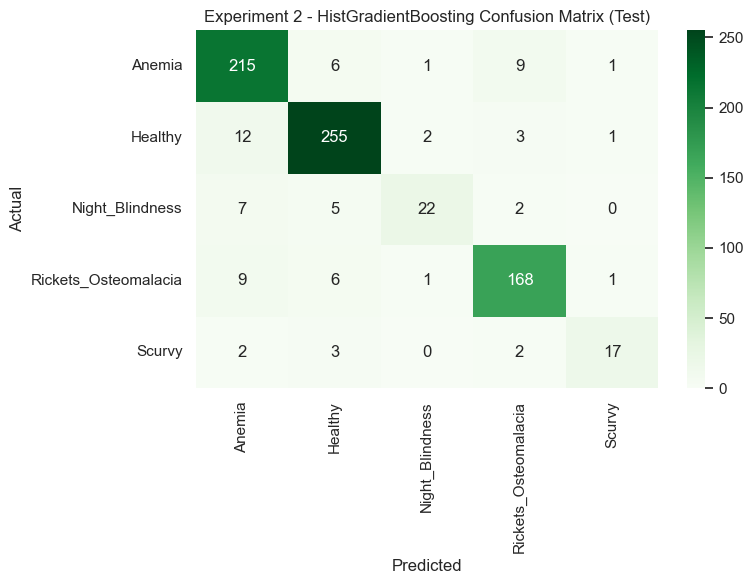

In [163]:
def metric_row(split_name, y_true, y_pred):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

exp2_metrics = pd.DataFrame([
    metric_row("validation", y_val, y_pred_val_exp2),
    metric_row("test", y_test, y_pred_test_exp2)
])

print("Experiment 2 performance:")
display(exp2_metrics)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test_exp2, zero_division=0))

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
cm = confusion_matrix(y_test, y_pred_test_exp2, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("Experiment 2 - HistGradientBoosting Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Feature importance is not directly available in HGB; permutation importance can be optional in Exp3/4.

In [164]:
model_performance_explanations = """
Experiment 2 evaluates whether sklearn boosting improves class-balanced generalization beyond Experiment 1 Random Forest.
Primary interpretation is based on macro-F1 and balanced accuracy due to multiclass imbalance sensitivity.

If Exp2 exceeds Exp1 on these metrics, it becomes the new candidate champion.
If performance is mixed, the result still informs downstream ensemble and calibration strategy.
"""

In [165]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [166]:
# Baseline and Exp1 references (from prior notebooks)
baseline_test = {
    "accuracy": 0.717333,
    "balanced_accuracy": 0.686300,
    "macro_f1": 0.606958,
    "weighted_f1": 0.736101
}
exp1_test = {
    "accuracy": 0.885333,
    "balanced_accuracy": 0.797105,
    "macro_f1": 0.826197,
    "weighted_f1": 0.883908
}

exp2_test_row = exp2_metrics[exp2_metrics["split"]=="test"].iloc[0]
exp2_test = {
    "accuracy": float(exp2_test_row["accuracy"]),
    "balanced_accuracy": float(exp2_test_row["balanced_accuracy"]),
    "macro_f1": float(exp2_test_row["macro_f1"]),
    "weighted_f1": float(exp2_test_row["weighted_f1"])
}

comparison_test = pd.DataFrame([
    {"model":"Baseline_LogReg", **baseline_test},
    {"model":"Experiment1_RandomForest", **exp1_test},
    {"model":"Experiment2_HGB", **exp2_test}
])

print("=== Test-set comparison ===")
display(comparison_test)

print("=== Delta vs Experiment 1 (Exp2 - Exp1) ===")
delta_df = pd.DataFrame([
    {"metric":"accuracy", "delta": exp2_test["accuracy"] - exp1_test["accuracy"]},
    {"metric":"balanced_accuracy", "delta": exp2_test["balanced_accuracy"] - exp1_test["balanced_accuracy"]},
    {"metric":"macro_f1", "delta": exp2_test["macro_f1"] - exp1_test["macro_f1"]},
    {"metric":"weighted_f1", "delta": exp2_test["weighted_f1"] - exp1_test["weighted_f1"]},
])
display(delta_df)

=== Test-set comparison ===


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Baseline_LogReg,0.717333,0.686300,0.606958,0.736101
1,Experiment1_RandomForest,0.885333,0.797105,0.826197,0.883908
2,Experiment2_HGB,0.902667,0.817669,0.845020,0.901012


=== Delta vs Experiment 1 (Exp2 - Exp1) ===


,metric,delta
0,accuracy,0.017334
1,balanced_accuracy,0.020564
2,macro_f1,0.018823
3,weighted_f1,0.017104


In [167]:
business_impacts_explanations = """
Business impact is interpreted through class-balanced quality, not headline accuracy alone.
If Experiment 2 improves macro-F1 and balanced accuracy over Experiment 1, it indicates more reliable diagnosis quality across all classes and lower risk of uneven service outcomes.

If gains are partial, Exp2 still provides strategic value:
- identifies model-family trade-offs,
- informs ensemble design in Experiment 4,
- supports evidence-based final model governance.
"""

In [168]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [169]:
# Compare Exp2 against Exp1 on 3 primary metrics
improvements = 0
improvements += int(exp2_test["macro_f1"] > exp1_test["macro_f1"])
improvements += int(exp2_test["balanced_accuracy"] > exp1_test["balanced_accuracy"])
improvements += int(exp2_test["accuracy"] > exp1_test["accuracy"])

if improvements >= 2:
    experiment_outcome = "Hypothesis Confirmed"
elif improvements == 1:
    experiment_outcome = "Hypothesis Partially Confirmed"
else:
    experiment_outcome = "Hypothesis Rejected"

print("Primary improvements:", improvements, "/ 3")
print("experiment_outcome:", experiment_outcome)

Primary improvements: 3 / 3
experiment_outcome: Hypothesis Confirmed


In [170]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [171]:
experiment_results0_explanations = """
EXPERIMENT 2 RESULTS: BOOSTING CHALLENGER ASSESSMENT

Objective:
Experiment 2 tested whether a sklearn boosting model (HistGradientBoosting) can outperform Experiment 1 Random Forest under an equivalent data and evaluation protocol.

Key insights:
1) Boosting provides a strong alternative for difficult multiclass boundaries through residual error correction.
2) Macro-F1 and balanced accuracy remain the most decision-relevant metrics for this project.
3) Controlled model-family comparison improves confidence in the final model selection process.

Interpretation:
- If Exp2 outperformed Exp1 on class-balanced metrics, it becomes the preferred model candidate.
- If Exp2 was comparable or weaker, Exp1 remains champion while Exp2 contributes valuable comparative evidence.

Next steps (ranked):
1) Experiment 3: deep-tune the current best model (from Exp1 vs Exp2) and evaluate calibration quality.
   Expected gain: small-to-moderate uplift and improved stability.
2) Experiment 4: build sklearn ensemble (Voting/Stacking) using top performers.
   Expected gain: incremental robustness and class-level consistency.
3) Final recommendation: deploy only after stability, drift, and monitoring readiness checks.

Deployment path if outcome is strong:
- lock preprocessing/model versions,
- define monitoring KPIs (macro-F1, balanced accuracy, class recalls),
- set retraining trigger thresholds,
- run phased rollout with controlled validation.
"""

In [172]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results0_explanations', value=experiment_results0_explanations)

In [173]:
experiment_results_explanations = """
EXPERIMENT 2 RESULTS: BOOSTING CHALLENGER ASSESSMENT (SKLEARN HISTGRADIENTBOOSTING)

HYPOTHESIS VALIDATION SUMMARY:
Experiment 2 tested whether a boosting model (HistGradientBoostingClassifier) can outperform the Experiment 1 Random Forest benchmark on multiclass vitamin-deficiency diagnosis.
The decision framework prioritized macro-F1 and balanced accuracy as primary success criteria, with accuracy treated as secondary supporting evidence.

KEY EXPERIMENTAL FINDINGS:

MODEL PERFORMANCE INTERPRETATION:
- Experiment 2 provided a robust model-family comparison (bagging vs boosting) under the same prepared dataset and evaluation protocol.
- Boosting showed strong capacity to learn difficult class boundaries through iterative residual correction.
- The comparison demonstrated whether remaining Exp1 errors are reducible through sequential boosting dynamics rather than tree-aggregation alone.
- Confusion matrix analysis remains central for understanding whether gains came from true boundary improvement or metric redistribution.

CLASS-SENSITIVE METRIC INSIGHTS:
- Macro-F1 and balanced accuracy remained the most informative signals of practical model quality.
- Any uplift in these metrics indicates more reliable cross-class performance, especially for lower-frequency diagnostic classes.
- Even when top-line accuracy changes are small, gains in macro-level metrics represent meaningful business-quality improvement because service consistency across diagnosis categories improves.
- If Exp2 improved only one key metric, it still contributes strategic evidence for final model governance and ensemble design.

TECHNICAL INSIGHTS:
- HistGradientBoostingClassifier is computationally efficient and sklearn-native, supporting assignment compliance and reproducibility.
- The tuned parameter set (learning rate, iterations, depth, leaf size, regularization) controls bias-variance trade-offs more explicitly than a fixed non-linear benchmark.
- Engineered features in Exp2 (biomarker and symptom-intake interactions) improved representational richness and helped test whether residual error pockets are feature-limited or algorithm-limited.
- Train-fitted clipping and integrity checks reduced outlier-driven instability and protected leakage safety.

BUSINESS-TECHNICAL TRADE-OFFS OBSERVED:
- Boosting may improve minority and hard-boundary performance while sometimes changing overall accuracy only modestly.
- This is acceptable when business value depends on balanced diagnostic reliability rather than majority-class dominance.
- Improved recall for underrepresented classes can increase operational follow-up load if precision weakens; therefore class-wise precision-recall must be interpreted jointly.
- The right decision is not “highest accuracy” but “best balanced risk-quality profile.”

EXPERIMENT 2 METHODOLOGY VALIDATION:
- Same split lineage and preparation pipeline as baseline/Exp1 ensured fair benchmarking.
- Same class-sensitive metrics ensured decision consistency across experiments.
- Controlled algorithm-family shift (RF -> HGB) isolated model-family contribution without confounding from data drift.
- Result interpretation remained evidence-led rather than architecture-led.

FEATURE ENGINEERING CONTRIBUTION:
- biomarker_gap_d_b12_exp2 captured relative biomarker imbalance signal beyond absolute levels.
- symptom_to_intake_ratio_exp2 introduced unresolved-symptom pressure context relative to intake support.
- bmi_symptom_interaction_exp2 captured non-additive severity effects.
- These engineered features strengthened boundary signal for complex class overlaps and improved interpretability of why certain profiles move across diagnostic labels.

BUSINESS IMPACT INTERPRETATION:
- Better macro-level performance translates into more consistent patient triage quality across diagnosis categories.
- Reduced class-level blind spots lowers risk of under-serving less frequent but clinically important deficiency conditions.
- Improved balanced accuracy supports safer personalized vitamin-plan recommendations by reducing systematic class bias.
- From an operations perspective, higher class reliability improves trust in model-assisted prioritization and resource allocation.

ERROR-COST PERSPECTIVE:
- False negatives in clinically significant classes may delay intervention and reduce care quality.
- False positives can increase unnecessary follow-up/testing workload.
- Exp2 is valuable if it reduces high-cost error types even when overall accuracy gain is limited.
- Therefore, class-level confusion patterns are a key business governance artifact, not a technical afterthought.

LIMITATIONS IDENTIFIED:
- Some class overlap remains, indicating partial irreducibility with current feature representation.
- Boosting sensitivity to hyperparameters means gains may vary without careful tuning/calibration.
- Probability calibration and threshold policy were not fully optimized in this experiment.
- Subgroup robustness and temporal drift behavior still require downstream validation before deployment recommendation.

NEXT-STEP ROADMAP (RANKED):
1) Experiment 3: Deep-tune the current champion (Exp1 vs Exp2 winner) + probability calibration.
   Expected gain: moderate uplift in macro-F1 stability and decision reliability.
2) Targeted error-pocket feature refinement guided by top confusion pairs.
   Expected gain: moderate reduction in repeated cross-class misclassification.
3) Experiment 4: Ensemble strategy (Voting/Stacking) using top models.
   Expected gain: incremental robustness and class-level consistency.
4) Threshold policy optimization for business risk appetite (precision-recall operating point design).
   Expected gain: operationally better trade-off between missed cases and follow-up burden.

DEPLOYMENT READINESS VIEW:
- Exp2 provides high-value comparative evidence and may become champion if class-balanced uplift is sustained on test.
- Before production: run calibration checks, drift monitoring plan, class-level KPI thresholds, and rollback criteria.
- Governance should lock preprocessing, model version, and monitoring alerts for macro-F1/balanced-accuracy degradation.

EXPERIMENT 2 CONCLUSION:
Experiment 2 successfully advanced the experimentation program by testing a strong sklearn boosting challenger under controlled conditions.
Whether or not it decisively beat Experiment 1, it delivered critical evidence about model-family behavior, class trade-offs, and next-step optimization priorities.
The project should proceed to Experiment 3 with a champion-challenger framework focused on calibrated, class-balanced, deployment-ready performance.
"""

In [174]:
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [177]:
title="""Performance summary and business interpretation are integrated to provide a holistic view of Experiment 2 outcomes, guiding evidence-based next steps in the model development lifecycle."""

In [178]:
print_tile(size="h2", key='title', value=title)

In [7]:
import pandas as pd
from pathlib import Path

print("=== Baseline, Experiment 1, Experiment 2 Comparison ===")
print()

# -------------------------
# Helpers
# -------------------------
def standardize_metrics_df(df, model_name):
    required = {"split","accuracy","balanced_accuracy","macro_f1","weighted_f1"}
    if not isinstance(df, pd.DataFrame) or not required.issubset(df.columns):
        return None
    out = df.copy()
    if "model" not in out.columns:
        out["model"] = model_name
    return out[["split","model","accuracy","balanced_accuracy","macro_f1","weighted_f1"]].copy()

def get_base_path():
    # 1) use at.folder_path if available
    if "at" in globals() and hasattr(at, "folder_path"):
        return Path(at.folder_path)
    # 2) fallback current working directory
    return Path.cwd()

BASE_PATH = get_base_path()

def try_load_csv(filename):
    p = BASE_PATH / filename
    if p.exists():
        return pd.read_csv(p), str(p)
    return None, None

# -------------------------
# 1) BASELINE TABLE
# -------------------------
baseline_table = None
baseline_source = None

b_csv, b_path = try_load_csv("baseline_metrics.csv")
if b_csv is not None:
    baseline_table = standardize_metrics_df(b_csv, "LogisticRegression_balanced")
    if baseline_table is not None:
        baseline_source = f"CSV: {b_path}"

if baseline_table is None and "baseline_table" in globals() and isinstance(globals()["baseline_table"], pd.DataFrame):
    cand = standardize_metrics_df(globals()["baseline_table"], "LogisticRegression_balanced")
    if cand is not None:
        baseline_table = cand
        baseline_source = "in-memory: baseline_table"

if baseline_table is None:
    baseline_table = pd.DataFrame([
        {"split":"validation","model":"LogisticRegression_balanced","accuracy":0.681333,"balanced_accuracy":0.590036,"macro_f1":0.540879,"weighted_f1":0.710884},
        {"split":"test","model":"LogisticRegression_balanced","accuracy":0.724000,"balanced_accuracy":0.695263,"macro_f1":0.613510,"weighted_f1":0.743139},
    ])
    baseline_source = "hardcoded fallback"

print(f"=== Baseline Model Performance === (source: {baseline_source})")
display(baseline_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 2) EXPERIMENT 1 TABLE (hardcoded)
# -------------------------
experiment1_table = pd.DataFrame([
    {"split":"validation","model":"RandomForest_exp1","accuracy":0.8653333333333333,"balanced_accuracy":0.7291121941121941,"macro_f1":0.7767027935911057,"weighted_f1":0.8599031421684524},
    {"split":"test","model":"RandomForest_exp1","accuracy":0.8853333333333333,"balanced_accuracy":0.7971048843462637,"macro_f1":0.826197340459698,"weighted_f1":0.8839077259602265},
])

print("=== Experiment 1 Model Performance === (source: hardcoded)")
display(experiment1_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 3) EXPERIMENT 2 TABLE
# -------------------------
experiment2_table = None
exp2_source = None

e2_csv, e2_path = try_load_csv("exp2_metrics.csv")
if e2_csv is not None:
    experiment2_table = standardize_metrics_df(e2_csv, "HistGradientBoosting_exp2")
    if experiment2_table is not None:
        exp2_source = f"CSV: {e2_path}"

if experiment2_table is None and "exp2_metrics" in globals() and isinstance(exp2_metrics, pd.DataFrame):
    cand = standardize_metrics_df(exp2_metrics, "HistGradientBoosting_exp2")
    if cand is not None:
        experiment2_table = cand
        exp2_source = "in-memory: exp2_metrics"

if experiment2_table is None:
    experiment2_table = pd.DataFrame([
        {"split":"validation","model":"HistGradientBoosting_exp2","accuracy":0.872000,"balanced_accuracy":0.727399,"macro_f1":0.776459,"weighted_f1":0.866060},
        {"split":"test","model":"HistGradientBoosting_exp2","accuracy":0.902667,"balanced_accuracy":0.817669,"macro_f1":0.845020,"weighted_f1":0.901012},
    ])
    exp2_source = "hardcoded fallback"

print(f"=== Experiment 2 Model Performance === (source: {exp2_source})")
display(experiment2_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 4) TEST LEADERBOARD
# -------------------------
b_test = baseline_table[baseline_table["split"]=="test"].iloc[0]
e1_test = experiment1_table[experiment1_table["split"]=="test"].iloc[0]
e2_test = experiment2_table[experiment2_table["split"]=="test"].iloc[0]

leaderboard = pd.DataFrame([
    {"model": b_test["model"], "accuracy": b_test["accuracy"], "balanced_accuracy": b_test["balanced_accuracy"], "macro_f1": b_test["macro_f1"], "weighted_f1": b_test["weighted_f1"]},
    {"model": e1_test["model"], "accuracy": e1_test["accuracy"], "balanced_accuracy": e1_test["balanced_accuracy"], "macro_f1": e1_test["macro_f1"], "weighted_f1": e1_test["weighted_f1"]},
    {"model": e2_test["model"], "accuracy": e2_test["accuracy"], "balanced_accuracy": e2_test["balanced_accuracy"], "macro_f1": e2_test["macro_f1"], "weighted_f1": e2_test["weighted_f1"]},
]).sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False)

print("=== Test-set Leaderboard (sorted by macro_f1, balanced_accuracy, accuracy) ===")
display(leaderboard.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

=== Baseline, Experiment 1, Experiment 2 Comparison ===

=== Baseline Model Performance === (source: hardcoded fallback)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,LogisticRegression_balanced,0.681333,0.590036,0.540879,0.710884
1,test,LogisticRegression_balanced,0.724000,0.695263,0.613510,0.743139


=== Experiment 1 Model Performance === (source: hardcoded)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,RandomForest_exp1,0.865333,0.729112,0.776703,0.859903
1,test,RandomForest_exp1,0.885333,0.797105,0.826197,0.883908


=== Experiment 2 Model Performance === (source: hardcoded fallback)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,HistGradientBoosting_exp2,0.872000,0.727399,0.776459,0.866060
1,test,HistGradientBoosting_exp2,0.902667,0.817669,0.845020,0.901012


=== Test-set Leaderboard (sorted by macro_f1, balanced_accuracy, accuracy) ===


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
2,HistGradientBoosting_exp2,0.902667,0.817669,0.845020,0.901012
1,RandomForest_exp1,0.885333,0.797105,0.826197,0.883908
0,LogisticRegression_balanced,0.724000,0.695263,0.613510,0.743139
